# ResNet Custom Model for Drone Acoustic Detection

In [1]:
! pip install torchmetrics pandas datasets numpy torchmetrics scikit-learn seaborn torchcodec torchaudio librosa ipywidgets torchvision wandb


  Using cached torchmetrics-1.8.2-py3-none-any.whl.metadata (22 kB)
  Using cached pandas-3.0.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached datasets-4.5.0-py3-none-any.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached torchcodec-0.10.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached torchaudio-2.10.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached torchvision-0.25.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached wandb-0.24.1-py3-none-manylinux_2_28_x86_64.whl.metadata (12 kB)
  Using cached lightning_utilities-0.15.2-py3-none-any.whl.metadata (5.7 kB)
  Using cached pyarrow-23.0.0-c

In [1]:
from datasets import load_from_disk, load_dataset, concatenate_datasets, DatasetDict
from IPython.lib.display import Audio as AudioDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, confusion_matrix, classification_report
from torch.utils.data import DataLoader
from torch import nn, optim
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import torchmetrics
import librosa
import random
import torch
import os


/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configurations

In [22]:
SEED = 42
BATCH_SIZE = 512
NUM_WORKERS = 24
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1.00E-01
MODEL_SAVE_PATH = "models/resnet_custom.3.pt"
EPOCHS=8
CLASS_NAMES = ["other", "drone"]


# Set seeds for reproducibility between runs
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Help reproducibility
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

print(f"Using device: {DEVICE}")
print(f"Number of workers: {NUM_WORKERS}")


Using device: cuda
Number of workers: 24


 ## Dataset & Collate function

In [23]:
# dataset = load_dataset("Hibou-Foundation/ds_121_melspecto_noaug_balanced_chunked")
# dataset = load_from_disk("../../dataset/ds_1_melspecto_aug_0-5_balanced_chunked.hf")
dataset = load_dataset("Hibou-Foundation/ds_121_melspecto_noaug_balanced_chunked")
dataset = dataset.with_format("torch", columns=["audio", "label"])

print("\nDataset splits:")
print({k: v.shape for k, v in dataset.items()})

print("\nDataset features:")
print(dataset["train"].features)



Dataset splits:
{'train': (352132, 2), 'val': (42198, 2), 'test': (44844, 2)}

Dataset features:
{'audio': List(List(List(Value('float64')))), 'label': ClassLabel(names=['other', 'drone'])}


In [24]:
def collate_fn(batch):
    """
    Prepares a batch for the model.
    """
    xs = []
    for audio in batch:
        xs.append(audio["audio"])

    ys = [b["label"] for b in batch]

    # Stack spectrograms into a batch
    # (B, H, W) -> (B, 1, H, W)
    xs = torch.stack(xs, dim=0)

    # Convert labels to float and add a dimension for BCEWithLogitsLoss
    # (B,) -> (B, 1)
    ys = torch.tensor(ys, dtype=torch.float32).unsqueeze(1)

    return xs, ys


train_loader = DataLoader(dataset["train"], batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
valid_loader = DataLoader(dataset["val"], batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(dataset["test"], batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f"\nCreated DataLoaders with Batch Size: {BATCH_SIZE}")

# Check a sample batch
try:
    sample_x, sample_y = next(iter(train_loader))
    print(f"Sample batch shape - X: {sample_x.shape}, Y: {sample_y.shape}")
except Exception as e:
    print(f"Could not load a sample batch: {e}")



Created DataLoaders with Batch Size: 512
Sample batch shape - X: torch.Size([512, 1, 128, 32]), Y: torch.Size([512, 1])


In [6]:
ds_all_tests = load_dataset("Hibou-Foundation/all_tests_ds_3")


In [7]:
def convert_to_mel_spectrogram(data):
    mel = librosa.feature.melspectrogram(
        y=data,
        sr=16000,
        n_fft=1025,
        hop_length=256,
        n_mels=128,
        fmin=20,
        fmax=8000,
        power=2.0
    )
     # Convert to log scale (dB)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    # Convert to torch tensor: [1, n_mels, time]
    mel_db = torch.tensor(mel_db).unsqueeze(0)

    return mel_db


def collate_fn_librosa_test(batch):
    inputs = []
    labels = []

    for item in batch:
        waveforme = item["audio"]["array"]
        wave = convert_to_mel_spectrogram(waveforme)
        inputs.append(wave)
        labels.append(item["label"])

    # Pad time dimension so all samples in batch have same T
    inputs = torch.nn.utils.rnn.pad_sequence(
        inputs, batch_first=True
    )

    labels = torch.tensor(labels, dtype=torch.float32)

    return inputs, labels


In [8]:
dataloaders = {}
for split in ds_all_tests.keys():
    ds = ds_all_tests[split]
    dataloaders[split] = DataLoader(
        ds,
        batch_size=1,
        shuffle=False,
        num_workers=1,
        collate_fn=collate_fn_librosa_test,
    )
dataloaders


{'drone_test': <torch.utils.data.dataloader.DataLoader at 0x7fc604775f30>,
 'drone_test_2': <torch.utils.data.dataloader.DataLoader at 0x7fc496317bb0>,
 'parabole1': <torch.utils.data.dataloader.DataLoader at 0x7fc489f8d490>,
 'parabole2': <torch.utils.data.dataloader.DataLoader at 0x7fc4963e78a0>,
 'parabole3': <torch.utils.data.dataloader.DataLoader at 0x7fc4963e6f10>,
 'parabole4': <torch.utils.data.dataloader.DataLoader at 0x7fc4963c7550>,
 'parabole5': <torch.utils.data.dataloader.DataLoader at 0x7fc4963c7d50>,
 'parabole6': <torch.utils.data.dataloader.DataLoader at 0x7fc4963c7950>,
 'parabole7': <torch.utils.data.dataloader.DataLoader at 0x7fc64c8ec050>}

## Model Definition

In [9]:
def norm(c):
    return nn.GroupNorm(num_groups=8, num_channels=c)

class SE(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(2),
            nn.Conv2d(c, c // r, kernel_size=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(c // r, c, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.fc(x)

class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=(1, 1)):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_c, out_c, kernel_size=(5, 3),
            stride=stride, padding=(2, 1), bias=False
        )
        self.bn1 = norm(out_c)
        self.act = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_c, out_c, kernel_size=(3, 3),
            stride=1, padding=1, bias=False
        )
        self.bn2 = norm(out_c)

        self.se = SE(out_c)

        self.shortcut = nn.Identity()
        if stride != (1, 1) or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, bias=False),
                norm(out_c)
            )

    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out = out + self.shortcut(x)
        return self.act(out)

class AudioResNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Stem: preserve time, reduce frequency
        self.conv1 = nn.Conv2d(
            1, 32, kernel_size=(5, 3),
            stride=(1, 2), padding=(2, 1), bias=False
        )
        self.bn1 = norm(32)
        self.act = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(
            kernel_size=(1, 3), stride=(2, 2), padding=(0, 1)
        )

        # Residual stages (6 blocks total)
        self.layer1 = self._make_layer(32, 64, blocks=2, stride=(1, 2))
        self.layer2 = self._make_layer(64, 128, blocks=2, stride=(2, 2))
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=(2, 2))

        # Pool frequency only
        self.freq_pool = nn.AdaptiveAvgPool2d((None, 1))

        # Temporal aggregation
        self.temporal = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1)
        )

        # Classifier
        self.fc = nn.Linear(128, 1)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [ResidualBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_c, out_c, stride=(1, 1)))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.act(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        # (B, C, T, F) -> pool F only
        x = self.freq_pool(x)
        x = x.squeeze(-1)     # (B, C, T)

        x = self.temporal(x)  # (B, 128, 1)
        x = x.squeeze(-1)

        return self.fc(x)


## Training Setup

In [10]:
model = AudioResNet().to(DEVICE)


In [11]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

metric_acc = torchmetrics.classification.BinaryAccuracy().to(DEVICE)


In [12]:
best_val_acc = 0.0
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

print("\nStarting training...")

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    metric_acc.reset()

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", unit="batch")

    for x, y in train_pbar:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        out = model(x)
        loss = criterion(out, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        running_train_loss += loss.item() * x.size(0)
        metric_acc.update(out, y)

        train_pbar.set_postfix(loss=loss.item())

    scheduler.step()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = metric_acc.compute().item()

    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)

    model.eval()
    running_val_loss = 0.0
    metric_acc.reset()

    valid_pbar = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]", unit="batch")

    with torch.no_grad():
        for x, y in valid_pbar:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            out = model(x)
            loss = criterion(out, y)

            running_val_loss += loss.item() * x.size(0)
            metric_acc.update(out, y)

            valid_pbar.set_postfix(loss=loss.item())

    epoch_val_loss = running_val_loss / len(valid_loader.dataset)
    epoch_val_acc = metric_acc.compute().item()

    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | "
          f"Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.4f}")

    # Save the best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Saved new best model to {MODEL_SAVE_PATH} (Val Acc: {best_val_acc:.4f})")

print("\nTraining complete.")



Starting training...


Epoch 1/5 [Valid]: 100%|██████████| 83/83 [00:05<00:00, 14.93batch/s, loss=0.0387]



Epoch 1/5 | Train Loss: 0.1248 | Train Acc: 0.9515 | Val Loss: 0.0608 | Val Acc: 0.9795
Saved new best model to models/resnet_custom.3.pt (Val Acc: 0.9795)


Epoch 2/5 [Valid]: 100%|██████████| 83/83 [00:05<00:00, 14.54batch/s, loss=0.0107]



Epoch 2/5 | Train Loss: 0.0398 | Train Acc: 0.9871 | Val Loss: 0.0344 | Val Acc: 0.9883
Saved new best model to models/resnet_custom.3.pt (Val Acc: 0.9883)


...


Epoch 3/5 | Train Loss: 0.0236 | Train Acc: 0.9927 | Val Loss: 0.0273 | Val Acc: 0.9908
Saved new best model to models/resnet_custom.3.pt (Val Acc: 0.9908)


Epoch 4/5 [Valid]: 100%|██████████| 83/83 [00:05<00:00, 14.66batch/s, loss=0.000851]



Epoch 4/5 | Train Loss: 0.0127 | Train Acc: 0.9963 | Val Loss: 0.0200 | Val Acc: 0.9941
Saved new best model to models/resnet_custom.3.pt (Val Acc: 0.9941)


Epoch 5/5 [Valid]: 100%|██████████| 83/83 [00:05<00:00, 13.89batch/s, loss=0.0014] 



Epoch 5/5 | Train Loss: 0.0058 | Train Acc: 0.9985 | Val Loss: 0.0177 | Val Acc: 0.9953
Saved new best model to models/resnet_custom.3.pt (Val Acc: 0.9953)

Training complete.


## Training Visualization

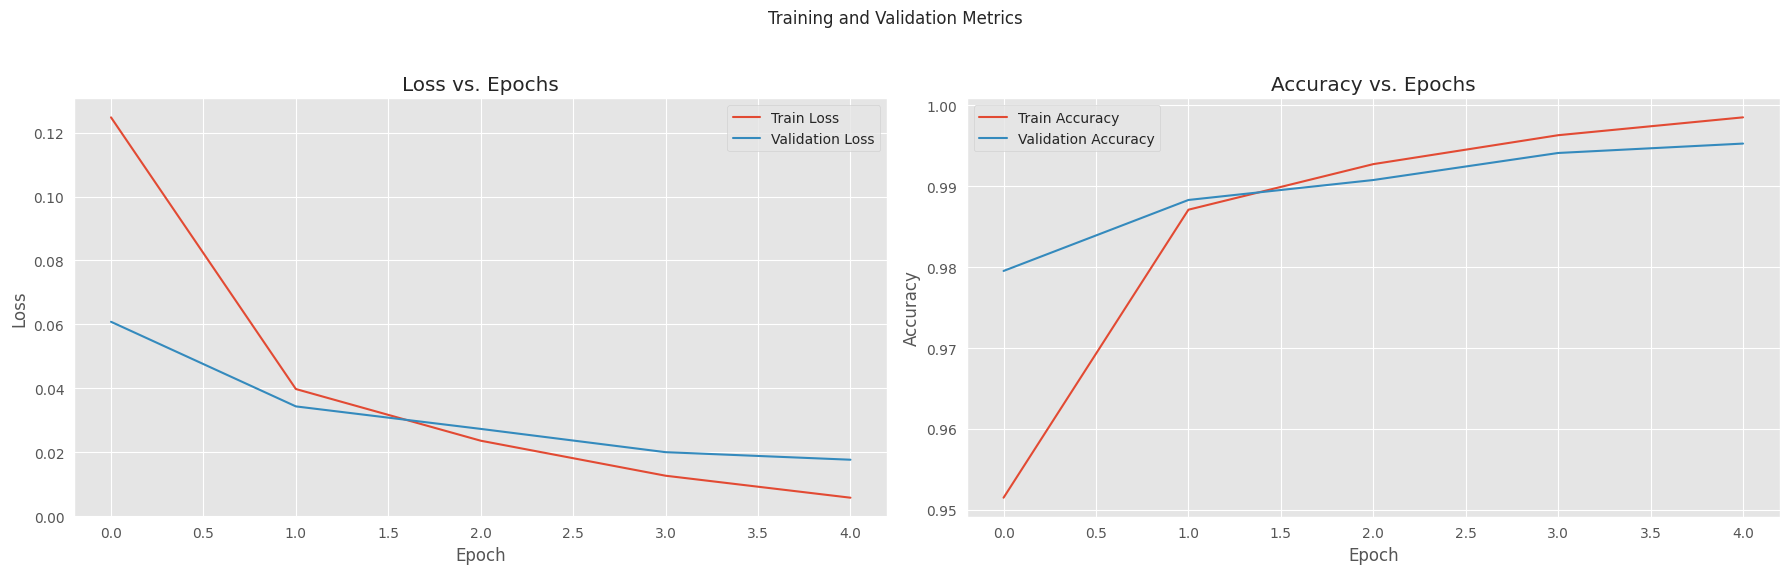

In [13]:
if history["train_loss"]:
    plt.style.use("ggplot")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot Loss
    ax1.plot(history["train_loss"], label="Train Loss")
    ax1.plot(history["val_loss"], label="Validation Loss")
    ax1.set_title("Loss vs. Epochs")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    # Plot Accuracy
    ax2.plot(history["train_acc"], label="Train Accuracy")
    ax2.plot(history["val_acc"], label="Validation Accuracy")
    ax2.set_title("Accuracy vs. Epochs")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.suptitle("Training and Validation Metrics")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


### Model loading and Test Evaluation

Change LOAD_MODEL_PATH to load a different model if needed

In [14]:
LOAD_MODEL_PATH = MODEL_SAVE_PATH
print(f"Loading best model from {LOAD_MODEL_PATH}...")
model = model.to(DEVICE)
model.load_state_dict(torch.load(LOAD_MODEL_PATH, map_location=DEVICE))
model.eval()
print("Loaded best model and set to eval mode.")


Loading best model from models/resnet_custom.3.pt...
Loaded best model and set to eval mode.


In [15]:
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(y.cpu().numpy().flatten())

print("\nTest evaluation complete.")


Testing: 100%|██████████| 88/88 [00:06<00:00, 13.01it/s]


Test evaluation complete.



Test Accuracy: 99.23%

Classification Report:
              precision    recall  f1-score   support

       other      0.990     0.995     0.992     22422
       drone      0.994     0.990     0.992     22422

    accuracy                          0.992     44844
   macro avg      0.992     0.992     0.992     44844
weighted avg      0.992     0.992     0.992     44844



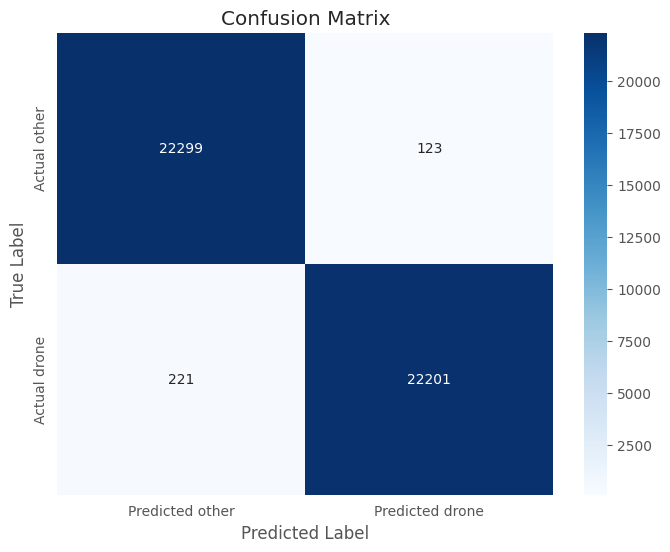


Results DataFrame head:
   true_label  pred_label  confidence
0         0.0         0.0    0.000589
1         0.0         0.0    0.005965
2         0.0         0.0    0.000064
3         0.0         0.0    0.000187
4         1.0         1.0    0.999998


In [16]:
accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")
target_names = dataset["train"].features["label"].names

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names, digits=3))
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Predicted {target_names[0]}", f"Predicted {target_names[1]}"],
            yticklabels=[f"Actual {target_names[0]}", f"Actual {target_names[1]}"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

df_results = pd.DataFrame({
    "true_label": all_labels,
    "pred_label": all_preds,
    "confidence": all_probs
})

print("\nResults DataFrame head:")
print(df_results.head())


## Evaluation on Custom Test Sets

In [17]:
results = {}
for split, loader in dataloaders.items():
    y_true, y_pred = [], []
    for x, y in tqdm(loader, desc=f"Testing {split}"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        y_pred.extend(preds.cpu().numpy().flatten())
        y_true.extend(y.cpu().numpy().flatten())
    results[split] = (y_true, y_pred)


Testing parabole7: 100%|██████████| 7953/7953 [00:28<00:00, 281.58it/s]


In [18]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except:
        auc = float("nan")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
    }

metrics = {}
for split, (y_true, y_pred) in results.items():
    metrics[split] = compute_metrics(y_true, y_pred)
    print(split, metrics[split])


drone_test {'accuracy': 0.6427771556550952, 'precision': 1.0, 'recall': 0.16927083333333334, 'f1': 0.289532293986637, 'auc': 0.5846354166666666, 'confusion_matrix': array([[509,   0],
       [319,  65]])}
drone_test_2 {'accuracy': 0.914795008912656, 'precision': 1.0, 'recall': 0.9147646219686163, 'f1': 0.9554851927733283, 'auc': 0.9573823109843081, 'confusion_matrix': array([[   1,    0],
       [ 239, 2565]])}
parabole1 {'accuracy': 0.7886178861788617, 'precision': 0.7549019607843137, 'recall': 0.9871794871794872, 'f1': 0.8555555555555555, 'auc': 0.7158119658119658, 'confusion_matrix': array([[20, 25],
       [ 1, 77]])}
parabole2 {'accuracy': 0.8705882352941177, 'precision': 0.8870967741935484, 'recall': 0.9322033898305084, 'f1': 0.9090909090909091, 'auc': 0.8314863102998696, 'confusion_matrix': array([[19,  7],
       [ 4, 55]])}
parabole3 {'accuracy': 0.43272727272727274, 'precision': 1.0, 'recall': 0.30666666666666664, 'f1': 0.46938775510204084, 'auc': 0.6533333333333333, 'confusi

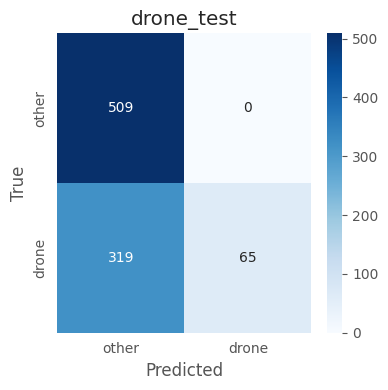

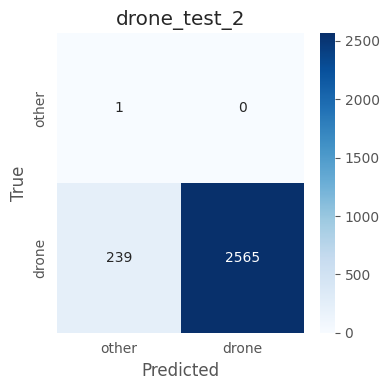

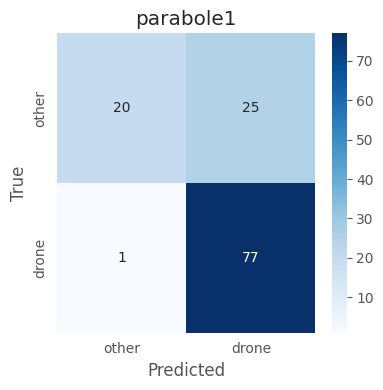

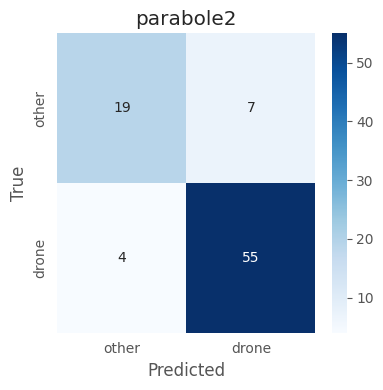

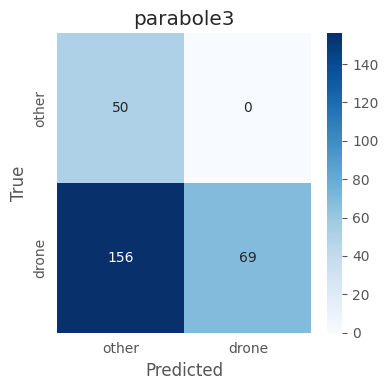

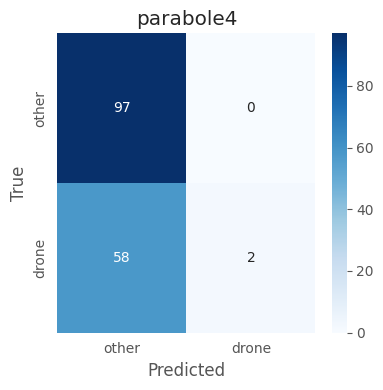

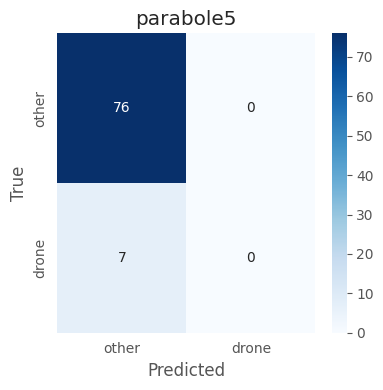

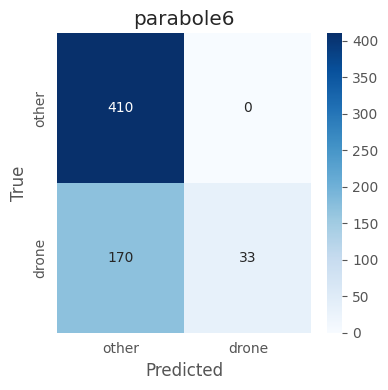

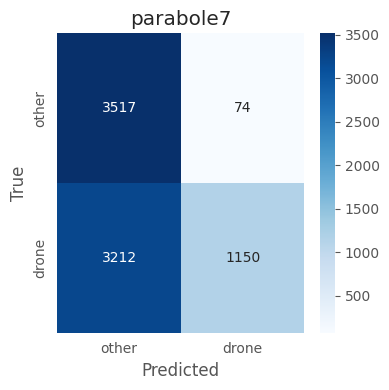

In [19]:
def plot_confusion(cm, title):
    plt.figure(figsize=(4,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for split, metric in metrics.items():
    plot_confusion(metric["confusion_matrix"], split)


## Custom Inference on WAV files

In [21]:
def infer_from_folder(folder_path: str):
    files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    results = []
    acc = 0

    for file in files:
        file_path = os.path.join(folder_path, file)
        waveform, sr = librosa.load(file_path, sr=16000)
        mel_spec = convert_to_mel_spectrogram(waveform).unsqueeze(0)
        mel_spec = mel_spec.to(DEVICE)

        with torch.no_grad():
            logits = model(mel_spec)
            probs = torch.sigmoid(logits).squeeze(1)
            pred = (probs > 0.5).float().cpu().item()
            confidence = probs.cpu().item()

        acc += pred
        print(file, int(pred), confidence)
        results.append({
            "file": file,
            "predicted_label": int(pred),
            "confidence": confidence
        })

    print("Acc: ", acc / len(files))

print(f"0 is {"other"}, 1 is {"drone"}")
infer_from_folder("/home/pierre/Documents/Projects/PST4/AI/data/raw/test/02-02-2026/other")

0 is other, 1 is drone
aigu_pierre1_chunk1.wav 0 0.0003150176489725709
aigu_pierre1_chunk2.wav 0 0.00012100577441742644
aigu_pierre1_chunk3.wav 0 5.901013355469331e-05
aigu_pierre1_chunk4.wav 0 0.00015700659423600882
aigu_pierre1_chunk5.wav 0 0.00012087995855836198
aigu_pierre1_chunk6.wav 0 0.000892251671757549
aigu_pierre1_chunk7.wav 0 4.998831718694419e-05
aigu_pierre1_chunk8.wav 0 0.00016189244342967868
aigu_pierre1_chunk9.wav 0 0.001051384024322033
aigu_pierre1_chunk10.wav 0 3.54393596353475e-05
aigu_pierre1_chunk11.wav 0 2.134379064955283e-05
aigu_pierre1_chunk12.wav 0 3.5905613913200796e-05
aigu_pierre1_chunk13.wav 0 2.8865704734926112e-05
aigu_pierre1_chunk14.wav 0 4.037320468341932e-05
aigu_pierre1_chunk15.wav 0 3.734349593287334e-05
aigu_pierre1_chunk16.wav 0 0.0006111361435614526
aigu_pierre1_chunk17.wav 0 0.0003354043001309037
aigu_pierre1_chunk18.wav 0 0.00017785702948458493
aigu_pierre1_chunk19.wav 0 0.002372776623815298
aigu_pierre1_chunk20.wav 0 0.00035000272328034043
ai